# 一、检测编码
使用python的chartdet库检测文件的编码形式

In [7]:
import pandas as pd
import chardet

# 步骤1：读取文件二进制内容，检测编码
with open("all-data.csv", "rb") as f:
    raw_data = f.read()  # 读取前10000字节（足够检测）
    result = chardet.detect(raw_data)
    encoding = result["encoding"]  # 检测出的编码
    confidence = result["confidence"]  # 检测置信度（越接近1越准）

print(f"检测到的编码格式：{encoding}，置信度：{confidence:.2f}")

# 步骤2：用检测到的编码加载CSV（自动处理常见编码兼容问题）
try:
    df = pd.read_csv("all-data.csv", encoding=encoding)
    print("✅ 编码正确，数据加载成功！")
    print(df.head())  # 验证数据是否正常显示
except Exception as e:
    # 兼容常见编码（latin-1是Kaggle英文数据的高频编码）
    print(f"❌ {encoding}编码加载失败，尝试latin-1编码...")
    df = pd.read_csv("all-data.csv", encoding="latin-1")
    print("✅ latin-1编码加载成功！")
    print(df.head())

检测到的编码格式：hp-roman8，置信度：0.93
✅ 编码正确，数据加载成功！
    neutral  \
0   neutral   
1  negative   
2  positive   
3  positive   
4  positive   

  According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .  
0  Technopolis plans to develop in stages an area...                                                                               
1  The international electronic industry company ...                                                                               
2  With the new production plant the company woul...                                                                               
3  According to the company 's updated strategy f...                                                                               
4  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...                                                                               


# 二、数据预处理
1. 确定这个是做一个金融新闻情感分析系统，所以需要保留正/中/负向的标题分类
2. 删除空值
3. 去除重复值

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. 加载数据（用检测到的正确编码）
df = pd.read_csv("data/data_process/all-data.csv", encoding="hp-roman8")

# 2. 第一步：查看数据列名（关键！先确认列名，避免操作错列）
print("原始数据列名：", df.columns.tolist())
# 从你的输出看，标签列名大概率是第一个列（显示为 neutral/negative/positive），先重命名列名方便操作
df.columns = ["label", "text"]  # 重命名：第一列=标签，第二列=文本（根据你的数据调整）
print(f"原数据量：{len(df)}")

# 3. 第二步：删除空白值（文本/标签为空的行都删除）
df = df.dropna(subset=["text", "label"]).reset_index(drop=True)
print(f"清理空白值后数据量：{len(df)}")

# 4. 第三步：异常值处理（删除文本长度异常的样本）
# 例如：文本过短（<3 个字符）或过长（>500 个字符）的视为异常
df["text_length"] = df["text"].apply(len)
original_len = len(df)
df = df[(df["text_length"] >= 3) & (df["text_length"] <= 500)].reset_index(drop=True)
print(f"异常值处理后数据量：{len(df)}（删除了{original_len - len(df)}条异常数据）")
# 删除临时列
df = df.drop(columns=["text_length"])

# 5. 第四步：去除重复值（基于 text 列去重）
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"去重复后最终数据量：{len(df)}")

# 6. 第五步：标签映射为数字（negative→0, positive→1, neutral→2）
label_mapping = {"negative": 0, "positive": 1, "neutral": 2}
df["label"] = df["label"].map(label_mapping)
print("\n标签映射完成！")
print(f"映射后的标签分布：")
print(df["label"].value_counts().sort_index())

# 7. 显示前 5 行数据预览
print("\n前 5 行数据预览：")
print(df.head())

# 8. （可选）保存清洗后的数据
# df.to_csv("cleaned_data.csv", index=False, encoding="utf-8")
# print("\n✅ 数据清洗完成！已保存到 cleaned_data.csv")


原始数据列名： ['neutral', 'According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .']
原数据量：4845
清理空白值后数据量：4845
异常值处理后数据量：4845（删除了0条异常数据）
去重复后最终数据量：4837

标签映射完成！
映射后的标签分布：
label
0     604
1    1362
2    2871
Name: count, dtype: int64

前 5 行数据预览：
   label                                               text
0      2  Technopolis plans to develop in stages an area...
1      0  The international electronic industry company ...
2      1  With the new production plant the company woul...
3      1  According to the company 's updated strategy f...
4      1  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


# 三、文本处理
1. 前面将table的标签映射为0/1/2了，接下来需要处理的是text的新闻标题，查看到这里的标题是英文的，所以不能使用jieba分词，应该使用nltk分词
2. 英文文本分词统计

✅ 分词完成！
示例分词结果：
['technopolis', 'plans', 'develop', 'stages', 'area', 'less', '100', '000', 'square', 'meters', 'order', 'host', 'companies', 'working', 'computer', 'technologies', 'telecommunications', 'statement', 'said']

📊 分词长度统计：
平均分词数：13.03
中位数分词数：12.00
最大分词数：48
最小分词数：0


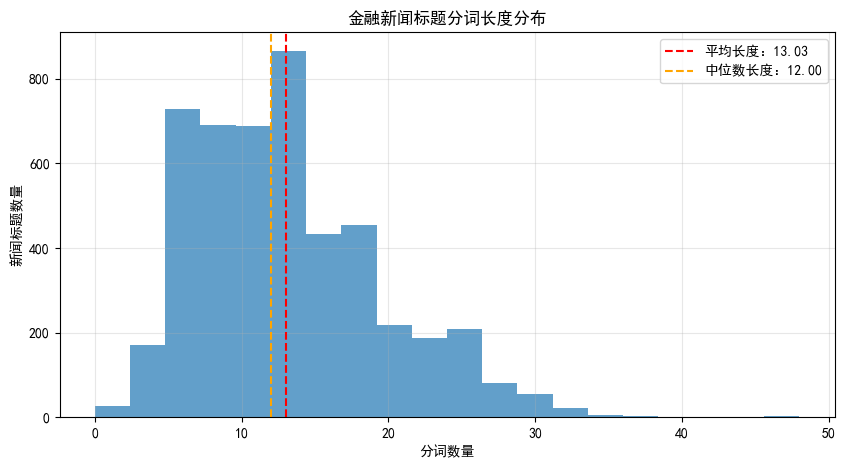

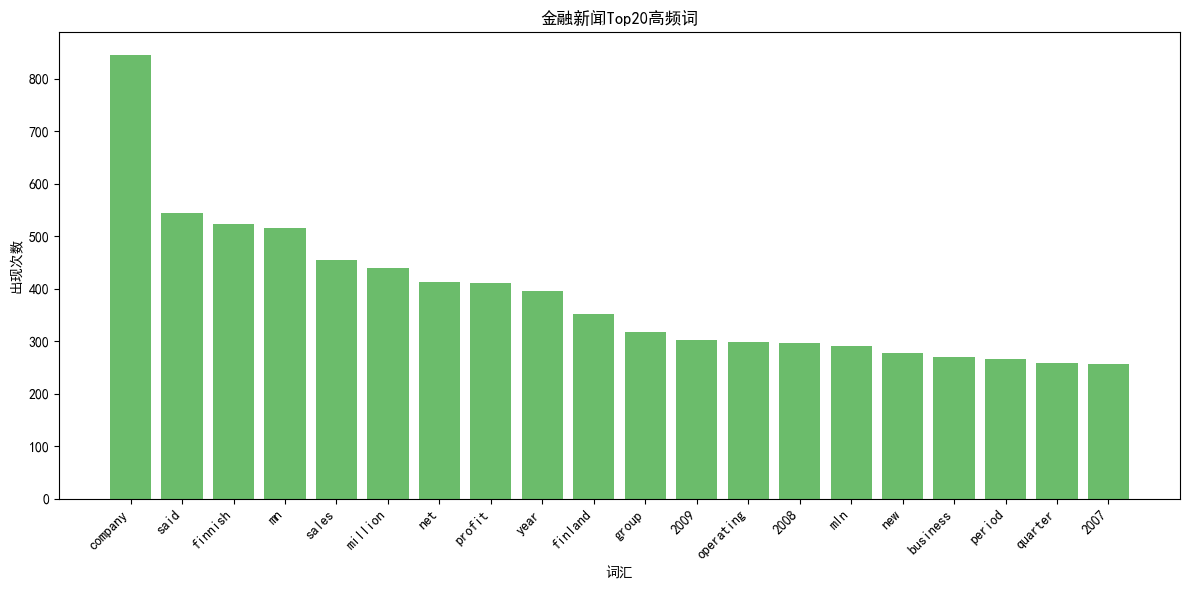


✅ 分词+词频统计完成！已保存分词后的数据到 tokenized_data.csv


In [24]:
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 微软雅黑
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 1. 下载NLTK资源（首次运行执行）
# nltk.download('punkt')
# nltk.download('stopwords')

# 2. 加载并读取处理好的CSV数据（已删neutral、空值、重复）
# df = pd.read_csv("processed_data.csv", encoding="hp-roman8")  # 替换为你的文件路径
# 确保text列是字符串类型
df["text"] = df["text"].astype(str)

# 3. 定义英文分词函数（核心，适配金融场景）
def english_tokenize(text):
    # 转小写
    text = text.lower()
    # 清洗特殊符号（保留字母、数字，去除标点/百分号等）
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    # 分词
    words = word_tokenize(text)
    # 过滤停用词+短词
    stop_words = set(stopwords.words('english'))
    # 补充金融场景停用词
    finance_stop = {"%", "$", "€", "usd", "eur", "the", "a", "an", "in", "of", "for", "on"}
    stop_words.update(finance_stop)
    # 过滤规则：非停用词 + 长度>1
    words = [w for w in words if w not in stop_words and len(w) > 1]
    return words

# 4. 全量分词（无泄露，固定规则）
df["tokenized_words"] = df["text"].apply(english_tokenize)
print("✅ 分词完成！")
print("示例分词结果：")
print(df["tokenized_words"].iloc[0])  # 打印第一条数据的分词结果

# 5. 统计分词长度（平均长度、分布）
df["token_length"] = df["tokenized_words"].apply(len)
avg_length = df["token_length"].mean()
median_length = df["token_length"].median()
print(f"\n📊 分词长度统计：")
print(f"平均分词数：{avg_length:.2f}")
print(f"中位数分词数：{median_length:.2f}")
print(f"最大分词数：{df['token_length'].max()}")
print(f"最小分词数：{df['token_length'].min()}")

# 6. 可视化分词长度分布（确定目标长度）
plt.figure(figsize=(10, 5))
plt.hist(df["token_length"], bins=20, color="#1f77b4", alpha=0.7)
plt.axvline(avg_length, color="red", linestyle="--", label=f"平均长度：{avg_length:.2f}")
plt.axvline(median_length, color="orange", linestyle="--", label=f"中位数长度：{median_length:.2f}")
plt.xlabel("分词数量")
plt.ylabel("新闻标题数量")
plt.title("金融新闻标题分词长度分布")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("img/data_split_img/token_length_dist.png")  # 保存图片
plt.show()

# 7. 统计全局词频（Top20高频词，分析核心特征）
all_words = []
for words in df["tokenized_words"]:
    all_words.extend(words)
word_freq = Counter(all_words)
top20_words = word_freq.most_common(20)

# 可视化Top20高频词
plt.figure(figsize=(12, 6))
words = [w[0] for w in top20_words]
counts = [w[1] for w in top20_words]
plt.bar(words, counts, color="#2ca02c", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.xlabel("词汇")
plt.ylabel("出现次数")
plt.title("金融新闻Top20高频词")
plt.tight_layout()
plt.savefig("img/data_split_img/top20_word_freq.png")
plt.show()

# 8. 保存分词后的数据（供后续固定长度/向量化使用）
df.to_csv("tokenized_data.csv", index=False, encoding="utf-8")
print("\n✅ 分词+词频统计完成！已保存分词后的数据到 tokenized_data.csv")

In [25]:
words = english_tokenize("According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .")

print(words)


['according', 'company', 'updated', 'strategy', 'years', '2009', '2012', 'basware', 'targets', 'long', 'term', 'net', 'sales', 'growth', 'range', '20', '40', 'operating', 'profit', 'margin', '10', '20', 'net', 'sales']


# 四、数据集划分
根据上面的分词统计，分词效果大概是在12-14个词效果是最好的，所以选择平均分词为13个数
1. 划分数据集为训练集和测试集（80%/20%）
3. 保存划分后的数据集（train.csv、test.csv）

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. 加载分词后的数据（替换为你的文件路径）
df = pd.read_csv("tokenized_data.csv", encoding="utf-8")

# 2. 关键：处理tokenized_words列的格式（字符串转列表，避免后续处理报错）
# 因为CSV中保存的是字符串形式的列表，需要转回真实列表
import ast
df["tokenized_words"] = df["tokenized_words"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 3. 分层划分训练集（80%）和测试集（20%）
# stratify=df["label"] 保证训练/测试集的正负样本比例和原数据一致
train_df, test_df = train_test_split(
    df,
    test_size=0.2,          # 测试集占20%
    random_state=42,        # 固定随机种子，结果可复现
    stratify=df["label"]    # 按标签分层，避免样本分布不均
)

# 4. 重置索引（可选，让索引从0开始，更整洁）
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# 5. 分别保存训练集和测试集
train_df.to_csv("data/data_process/train_split_data.csv", index=False, encoding="utf-8")
test_df.to_csv("data/data_process/test_split_data.csv", index=False, encoding="utf-8")

# 6. 验证划分结果
print(f"原始数据总量：{len(df)}")
print(f"训练集数量：{len(train_df)}（{len(train_df)/len(df)*100:.1f}%）")
print(f"测试集数量：{len(test_df)}（{len(test_df)/len(df)*100:.1f}%）")
print("\n训练集标签分布：")
print(train_df["label"].value_counts())
print("\n测试集标签分布：")
print(test_df["label"].value_counts())

原始数据总量：4837
训练集数量：3869（80.0%）
测试集数量：968（20.0%）

训练集标签分布：
label
2    2297
1    1089
0     483
Name: count, dtype: int64

测试集标签分布：
label
2    574
1    273
0    121
Name: count, dtype: int64


# 五、数据预处理
加载train_data.csv，基于训练集的分词计算 TF-IDF 权重；
对训练集 / 测试集分别执行 “保留权重前 13 个词 + 不足使用PAD 填充” 的操作；
全程保证：权重规则仅从训练集学习，测试集仅复用规则。

In [27]:
import pandas as pd
import ast
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.decomposition import PCA  # 降维工具
from sklearn.preprocessing import StandardScaler  # 标准化（降维前必备）

# -------------------------- 1. 加载训练/测试集并恢复分词格式 --------------------------
train_df = pd.read_csv("data/data_process/train_split_data.csv", encoding="utf-8")
test_df = pd.read_csv("data/data_process/test_split_data.csv", encoding="utf-8")

train_df["tokenized_words"] = train_df["tokenized_words"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
test_df["tokenized_words"] = test_df["tokenized_words"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# -------------------------- 2. 训练TF-IDF + 固定13个分词 --------------------------
train_texts = [" ".join(words) for words in train_df["tokenized_words"]]
tfidf = TfidfVectorizer()
tfidf.fit(train_texts)

def fix_token_length(tokens, tfidf_model, max_len=13):
    if len(tokens) == 0:
        return ["<PAD>"] * max_len
    token_weights = [(t, tfidf_model.idf_[tfidf_model.vocabulary_[t]] if t in tfidf_model.vocabulary_ else 0.0) for t in tokens]
    sorted_tokens = sorted(token_weights, key=lambda x: x[1], reverse=True)[:max_len]
    selected_tokens = [t[0] for t in sorted_tokens]
    selected_tokens += ["<PAD>"] * (max_len - len(selected_tokens))
    return selected_tokens

train_df["fixed_tokens"] = train_df["tokenized_words"].apply(lambda x: fix_token_length(x, tfidf))
test_df["fixed_tokens"] = test_df["tokenized_words"].apply(lambda x: fix_token_length(x, tfidf))

# -------------------------- 3. 训练50维Word2Vec + 生成13×50二维向量 --------------------------
train_corpus = train_df["fixed_tokens"].tolist()
w2v_model = Word2Vec(
    sentences=train_corpus,
    vector_size=50,
    window=5,
    min_count=1,
    workers=4,
    seed=42
)

# 生成13×50二维数组（保留原始维度，不拼接）
def token_to_2d_vector(tokens, w2v_model, vec_dim=50):
    vec_list = []
    for token in tokens:
        vec = w2v_model.wv[token] if token in w2v_model.wv else np.zeros(vec_dim)
        vec_list.append(vec)
    # 返回13×50二维数组（shape=(13,50)）
    return np.array(vec_list)

train_df["vector_2d"] = train_df["fixed_tokens"].apply(lambda x: token_to_2d_vector(x, w2v_model))
test_df["vector_2d"] = test_df["fixed_tokens"].apply(lambda x: token_to_2d_vector(x, w2v_model))

# -------------------------- 4. 降维：13×50 → 低维特征（以降为100维为例） --------------------------
# 步骤4.1：整理训练集二维向量为矩阵（样本数 × 650），用于降维拟合
# 先把每个样本的13×50二维数组展平为650维一维数组（仅用于降维拟合，非最终输入）
train_vectors_flat = np.array([vec.flatten() for vec in train_df["vector_2d"]])
test_vectors_flat = np.array([vec.flatten() for vec in test_df["vector_2d"]])

# 步骤4.2：标准化（降维前必须做，避免量纲影响）
scaler = StandardScaler()
train_vectors_scaled = scaler.fit_transform(train_vectors_flat)  # 仅用训练集拟合scaler
test_vectors_scaled = scaler.transform(test_vectors_flat)       # 测试集复用

# 步骤4.3：PCA降维（650维 → 100维，可根据需求调整n_components）
# 降维维度建议：小数据集选100维，既能压缩维度，又保留核心语义
pca = PCA(n_components=100, random_state=42)
train_vectors_pca = pca.fit_transform(train_vectors_scaled)      # 仅用训练集拟合PCA
test_vectors_pca = pca.transform(test_vectors_scaled)            # 测试集复用

# 步骤4.4：将降维后的向量放回DataFrame
train_df["vector_pca"] = list(train_vectors_pca)
test_df["vector_pca"] = list(test_vectors_pca)

# -------------------------- 5. 验证结果 + 保存 --------------------------
print(f"原始二维向量形状：{train_df['vector_2d'].iloc[0].shape}（13×50）")
print(f"展平后维度：{train_vectors_flat.shape[1]}（650维）")
print(f"PCA降维后维度：{train_vectors_pca.shape[1]}（100维）")
print(f"PCA解释方差比：{np.sum(pca.explained_variance_ratio_):.2f}（保留{np.sum(pca.explained_variance_ratio_)*100:.1f}%信息）")

# 保存最终数据（保留二维向量+降维后向量）
train_final = train_df[["label", "fixed_tokens", "vector_2d", "vector_pca"]]
test_final = test_df[["label", "fixed_tokens", "vector_2d", "vector_pca"]]
train_final.to_csv("train_data.csv", index=False, encoding="utf-8")
test_final.to_csv("test_data.csv", index=False, encoding="utf-8")

原始二维向量形状：(13, 50)（13×50）
展平后维度：650（650维）
PCA降维后维度：100（100维）
PCA解释方差比：0.98（保留98.3%信息）


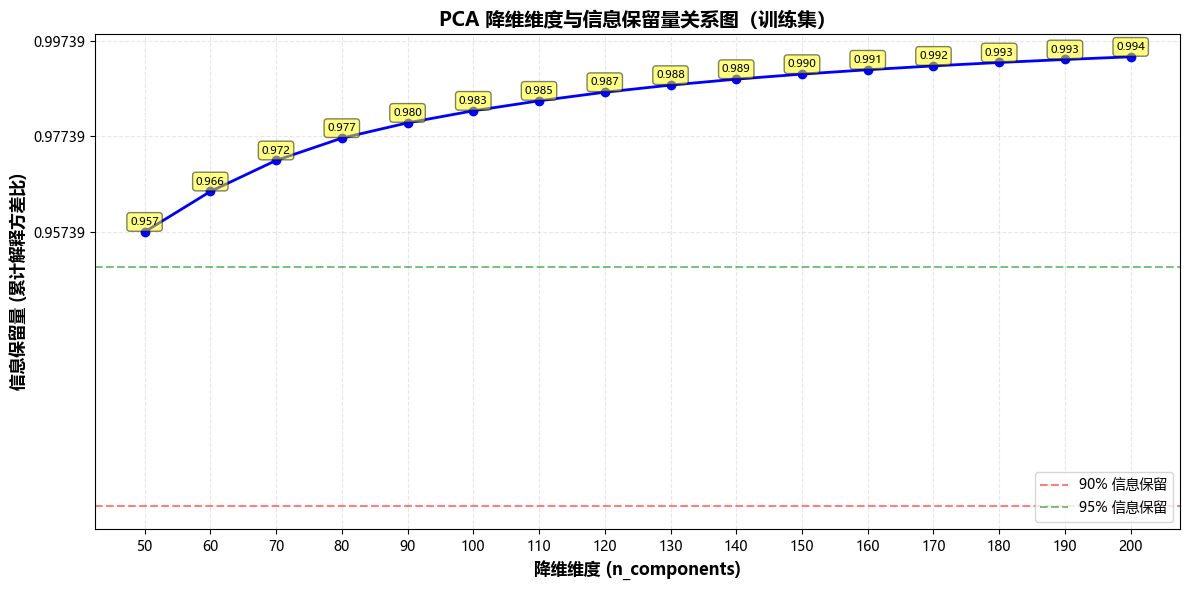


=== PCA 降维维度选择分析 ===
50维：信息保留量 0.9574 (95.74%)
60维：信息保留量 0.9658 (96.58%)
70维：信息保留量 0.9723 (97.23%)
80维：信息保留量 0.9770 (97.70%)
90维：信息保留量 0.9802 (98.02%)
100维：信息保留量 0.9827 (98.27%)
110维：信息保留量 0.9848 (98.48%)
120维：信息保留量 0.9866 (98.66%)
130维：信息保留量 0.9881 (98.81%)
140维：信息保留量 0.9893 (98.93%)
150维：信息保留量 0.9904 (99.04%)
160维：信息保留量 0.9913 (99.13%)
170维：信息保留量 0.9921 (99.21%)
180维：信息保留量 0.9928 (99.28%)
190维：信息保留量 0.9934 (99.34%)
200维：信息保留量 0.9940 (99.40%)


In [2]:
import pandas as pd
import ast
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.decomposition import PCA  # 降维工具
from sklearn.preprocessing import StandardScaler  # 标准化（降维前必备）

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False


# -------------------------- 1. 加载训练/测试集并恢复分词格式 --------------------------
train_df = pd.read_csv("data/data_process/train_split_data.csv", encoding="utf-8")
test_df = pd.read_csv("data/data_process/test_split_data.csv", encoding="utf-8")

train_df["tokenized_words"] = train_df["tokenized_words"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
test_df["tokenized_words"] = test_df["tokenized_words"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# -------------------------- 2. 训练TF-IDF + 固定13个分词 --------------------------
train_texts = [" ".join(words) for words in train_df["tokenized_words"]]
tfidf = TfidfVectorizer()
tfidf.fit(train_texts)

def fix_token_length(tokens, tfidf_model, max_len=13):
    if len(tokens) == 0:
        return ["<PAD>"] * max_len
    token_weights = [(t, tfidf_model.idf_[tfidf_model.vocabulary_[t]] if t in tfidf_model.vocabulary_ else 0.0) for t in tokens]
    sorted_tokens = sorted(token_weights, key=lambda x: x[1], reverse=True)[:max_len]
    selected_tokens = [t[0] for t in sorted_tokens]
    selected_tokens += ["<PAD>"] * (max_len - len(selected_tokens))
    return selected_tokens

train_df["fixed_tokens"] = train_df["tokenized_words"].apply(lambda x: fix_token_length(x, tfidf))
test_df["fixed_tokens"] = test_df["tokenized_words"].apply(lambda x: fix_token_length(x, tfidf))

# -------------------------- 3. 训练50维Word2Vec + 生成13×50二维向量 --------------------------
train_corpus = train_df["fixed_tokens"].tolist()
w2v_model = Word2Vec(
    sentences=train_corpus,
    vector_size=50,
    window=5,
    min_count=1,
    workers=4,
    seed=42
)

# 生成13×50二维数组（保留原始维度，不拼接）
def token_to_2d_vector(tokens, w2v_model, vec_dim=50):
    vec_list = []
    for token in tokens:
        vec = w2v_model.wv[token] if token in w2v_model.wv else np.zeros(vec_dim)
        vec_list.append(vec)
    # 返回13×50二维数组（shape=(13,50)）
    return np.array(vec_list)

train_df["vector_2d"] = train_df["fixed_tokens"].apply(lambda x: token_to_2d_vector(x, w2v_model))
test_df["vector_2d"] = test_df["fixed_tokens"].apply(lambda x: token_to_2d_vector(x, w2v_model))


# -------------------------- 4. 降维：13×50 → 低维特征（以降为 100 维为例） --------------------------
# 步骤 4.1：整理训练集二维向量为矩阵（样本数 × 650），用于降维拟合
# 先把每个样本的 13×50 二维数组展平为 650 维一维数组（仅用于降维拟合，非最终输入）
train_vectors_flat = np.array([vec.flatten() for vec in train_df["vector_2d"]])
test_vectors_flat = np.array([vec.flatten() for vec in test_df["vector_2d"]])

# 步骤 4.2：标准化（降维前必须做，避免量纲影响）
scaler = StandardScaler()
train_vectors_scaled = scaler.fit_transform(train_vectors_flat)  # 仅用训练集拟合 scaler
test_vectors_scaled = scaler.transform(test_vectors_flat)       # 测试集复用

# -------------------------- 4.5:PCA 降维维度与信息保留量可视化（50-200 维） --------------------------
from matplotlib import pyplot as plt

# 测试不同的降维维度（从 50 到 200 维）
dimensions = range(50, 201, 10)
explained_variances = []

for n_comp in dimensions:
    pca_temp = PCA(n_components=n_comp, random_state=42)
    pca_temp.fit(train_vectors_scaled)
    total_variance = np.sum(pca_temp.explained_variance_ratio_)
    explained_variances.append(total_variance)

# 绘制维度 - 信息保留量曲线
plt.figure(figsize=(12, 6))
plt.plot(dimensions, explained_variances, 'bo-', linewidth=2, markersize=6)
plt.xlabel('降维维度 (n_components)', fontsize=12, fontweight='bold')
plt.ylabel('信息保留量 (累计解释方差比)', fontsize=12, fontweight='bold')
plt.title('PCA 降维维度与信息保留量关系图（训练集）', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(range(50, 201, 10))
plt.yticks(np.arange(min(explained_variances), max(explained_variances) + 0.01, 0.02))

# 在图上标注具体数值
for i, (dim, var) in enumerate(zip(dimensions, explained_variances)):
    plt.annotate(f'{var:.3f}', 
                 xy=(dim, var), 
                 xytext=(0, 5), 
                 textcoords='offset points',
                 ha='center', 
                 fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# 添加参考线（90%、95% 信息保留量）
plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.5, label='90% 信息保留')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.5, label='95% 信息保留')
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('pca_dimension_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印关键信息
print("\n=== PCA 降维维度选择分析 ===")
for dim, var in zip(dimensions, explained_variances):
    print(f"{dim}维：信息保留量 {var:.4f} ({var*100:.2f}%)")

# 步骤 4.3：PCA 降维（650 维 → 100 维，可根据需求调整 n_components）
# 降维维度建议：小数据集选 100 维，既能压缩维度，又保留核心语义
pca = PCA(n_components=100, random_state=42)
train_vectors_pca = pca.fit_transform(train_vectors_scaled)      # 仅用训练集拟合 PCA
test_vectors_pca = pca.transform(test_vectors_scaled)            # 测试集复用

# 步骤 4.4：将降维后的向量放回 DataFrame
train_df["vector_pca"] = list(train_vectors_pca)
test_df["vector_pca"] = list(test_vectors_pca)

# ... existing code ...

# Deleted:# 保存最终数据（保留二维向量 + 降维后向量）
# Deleted:train_final = train_df[["label", "fixed_tokens", "vector_2d", "vector_pca"]]
# Deleted:test_final = test_df[["label", "fixed_tokens", "vector_2d", "vector_pca"]]
# Deleted:train_final.to_csv("train_data.csv", index=False, encoding="utf-8")
# Deleted:test_final.to_csv("test_data.csv", index=False, encoding="utf-8")



In [3]:
import pandas as pd
import ast
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.decomposition import PCA  # 降维工具
from sklearn.preprocessing import StandardScaler  # 标准化（降维前必备）

# -------------------------- 1. 加载训练/测试集并恢复分词格式 --------------------------
train_df = pd.read_csv("data/data_process/train_split_data.csv", encoding="utf-8")
test_df = pd.read_csv("data/data_process/test_split_data.csv", encoding="utf-8")

train_df["tokenized_words"] = train_df["tokenized_words"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
test_df["tokenized_words"] = test_df["tokenized_words"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# -------------------------- 2. 训练TF-IDF + 固定13个分词 --------------------------
train_texts = [" ".join(words) for words in train_df["tokenized_words"]]
tfidf = TfidfVectorizer()
tfidf.fit(train_texts)

def fix_token_length(tokens, tfidf_model, max_len=13):
    if len(tokens) == 0:
        return ["<PAD>"] * max_len
    token_weights = [(t, tfidf_model.idf_[tfidf_model.vocabulary_[t]] if t in tfidf_model.vocabulary_ else 0.0) for t in tokens]
    sorted_tokens = sorted(token_weights, key=lambda x: x[1], reverse=True)[:max_len]
    selected_tokens = [t[0] for t in sorted_tokens]
    selected_tokens += ["<PAD>"] * (max_len - len(selected_tokens))
    return selected_tokens

train_df["fixed_tokens"] = train_df["tokenized_words"].apply(lambda x: fix_token_length(x, tfidf))
test_df["fixed_tokens"] = test_df["tokenized_words"].apply(lambda x: fix_token_length(x, tfidf))

# -------------------------- 3. 训练50维Word2Vec + 生成13×50二维向量 --------------------------
train_corpus = train_df["fixed_tokens"].tolist()
w2v_model = Word2Vec(
    sentences=train_corpus,
    vector_size=50,
    window=5,
    min_count=1,
    workers=4,
    seed=42
)

# 生成13×50二维数组（保留原始维度，不拼接）
def token_to_2d_vector(tokens, w2v_model, vec_dim=50):
    vec_list = []
    for token in tokens:
        vec = w2v_model.wv[token] if token in w2v_model.wv else np.zeros(vec_dim)
        vec_list.append(vec)
    # 返回13×50二维数组（shape=(13,50)）
    return np.array(vec_list)

train_df["vector_2d"] = train_df["fixed_tokens"].apply(lambda x: token_to_2d_vector(x, w2v_model))
test_df["vector_2d"] = test_df["fixed_tokens"].apply(lambda x: token_to_2d_vector(x, w2v_model))

# -------------------------- 4. 降维：13×50 → 低维特征（以降为100维为例） --------------------------
# 步骤4.1：整理训练集二维向量为矩阵（样本数 × 650），用于降维拟合
# 先把每个样本的13×50二维数组展平为650维一维数组（仅用于降维拟合，非最终输入）
train_vectors_flat = np.array([vec.flatten() for vec in train_df["vector_2d"]])
test_vectors_flat = np.array([vec.flatten() for vec in test_df["vector_2d"]])

# 步骤4.2：标准化（降维前必须做，避免量纲影响）
scaler = StandardScaler()
train_vectors_scaled = scaler.fit_transform(train_vectors_flat)  # 仅用训练集拟合scaler
test_vectors_scaled = scaler.transform(test_vectors_flat)       # 测试集复用


# 步骤 4.3：PCA 降维（650 维 → 80 维）
pca = PCA(n_components=80, random_state=42)
train_vectors_pca = pca.fit_transform(train_vectors_scaled)
test_vectors_pca = pca.transform(test_vectors_scaled)
total_variance = np.sum(pca.explained_variance_ratio_)

# 步骤4.4：将降维后的向量放回DataFrame
train_df["vector_pca"] = list(train_vectors_pca)
test_df["vector_pca"] = list(test_vectors_pca)

# Deleted:print(f"PCA 降维后维度：{train_vectors_pca.shape[1]}（100 维）")
print(f"PCA 降维后维度：{train_vectors_pca.shape[1]}（80 维）")
print(f"信息保留量：{total_variance:.4f} ({total_variance*100:.2f}%)")
print(f"信息损失量：{1-total_variance:.4f} ({(1-total_variance)*100:.2f}%)")

# ... existing code ...

# # 保存最终数据（保留二维向量 + 降维后向量）
train_final = train_df[["label", "fixed_tokens", "vector_2d", "vector_pca"]]
test_final = test_df[["label", "fixed_tokens", "vector_2d", "vector_pca"]]
train_final.to_csv("train_data_80.csv", index=False, encoding="utf-8")
test_final.to_csv("test_data_80.csv", index=False, encoding="utf-8")


PCA 降维后维度：80（80 维）
信息保留量：0.9762 (97.62%)
信息损失量：0.0238 (2.38%)


# 六、查看处理好之后的数据


In [29]:
import pandas as pd

df = pd.read_csv("train_data.csv", encoding="utf-8")
print(df.head(5))
print(df.info())
print(df.shape)

   label                                       fixed_tokens  \
0      2  ['dissolve', 'zao', 'scandic', 'northwest', 'a...   
1      1  ['tahko', 'resort', 'holiday', 'spa', 'ski', '...   
2      2  ['host', 'stages', 'meters', 'computer', 'less...   
3      2  ['capped', 'achievement', 'eur12m', 'payable',...   
4      2  ['woodworking', 'sheksna', 'vologda', 'northwe...   

                                           vector_2d  \
0  [[-1.10171828e-02 -2.40047090e-03  1.42893028e...   
1  [[ 8.83766077e-03 -2.52337884e-02 -1.68201029e...   
2  [[-1.90704931e-02 -2.60977298e-02  1.04596522e...   
3  [[-1.45252440e-02  2.08737189e-03 -2.67912168e...   
4  [[-1.94396228e-02 -2.04363409e-02  7.39516830e...   

                                          vector_pca  
0  [ 1.58222036e+01  5.88830948e+00  1.31094551e+...  
1  [ 1.63083382e+01  4.04145527e+00  1.27644253e+...  
2  [13.847893    1.6881359   4.077301    0.458749...  
3  [ 1.4639762e+01  4.5480785e+00 -8.2581002e-01 ...  
4  [ 1.55

In [32]:
# 直接看第一行数据的样子
print("第一行完整数据：")
print(df.iloc[0])
print(df.shape)

# 看 vector_2d 的长度
first_vec_str = df['vector_2d'].iloc[0]
print(f"\nvector_2d 字符串长度：{len(first_vec_str)}")
print(f"vector_2d 字符串前50个字符：{first_vec_str[:50]}")

# 数数有多少个数字
numbers = first_vec_str.strip('[]').split()
print(f"vector_2d 包含的数字个数：{len(numbers)}")

第一行完整数据：
label                                                           2
fixed_tokens    ['dissolve', 'zao', 'scandic', 'northwest', 'a...
vector_2d       [[-1.10171828e-02 -2.40047090e-03  1.42893028e...
vector_pca      [ 1.58222036e+01  5.88830948e+00  1.31094551e+...
Name: 0, dtype: object
(3869, 4)

vector_2d 字符串长度：10751
vector_2d 字符串前50个字符：[[-1.10171828e-02 -2.40047090e-03  1.42893028e-02 
vector_2d 包含的数字个数：652


class ThinkingProcess:
    """
    构建情感分析系统的思考步骤
    """
    
    def step1_理解问题(self):
        """搞清楚我们要做什么"""
        return {
            '任务': '新闻标题情感分类',
            '输入': '100维向量（已处理好的文本特征）',
            '输出': '0/1/2 三分类',
            '难点': '情感细微差别，数据可能不平衡'
        }
    
    def step2_建立基准(self):
        """先用简单方法试试"""
        # 逻辑回归作为基准
        # 如果简单模型效果就很好，可能不需要复杂模型
        
    def step3_多样尝试(self):
        """用不同类型的算法尝试"""
        algorithms = [
            '线性模型：逻辑回归',
            '核方法：SVM',
            '树模型：随机森林、XGBoost',
            '神经网络：MLP'
        ]
        # 每种算法都有不同的"视角"
    
    def step4_寻找最佳(self):
        """对每个算法调参，找到其最佳状态"""
        # 就像每个选手经过最佳训练后参赛
        
    def step5_公正比较(self):
        """用统一的标准比较所有算法"""
        metrics = ['准确率', '精确率', '召回率', 'F1']
        # F1作为主要评判标准
        
    def step6_可视化诊断(self):
        """通过图表发现问题"""
        plots = [
            '柱状图：算法对比',
            '混淆矩阵：错误分析',
            '学习曲线：数据量影响'
        ]
        
    def step7_集成优化(self):
        """组合最好的几个模型"""
        # 取长补短，发挥组合优势